In [1]:
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore", category=FutureWarning)

import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(message)s", datefmt="%H:%M:%S")

import numpy as np
import pandas as pd

from src.ml.data import get_train_val_test_splits
from src.ml.evaluate import (
    load_all_models,
    binary_score_rf, binary_score_xgb, binary_score_iforest,
    plot_roc_comparison, plot_pr_comparison,
    per_class_detection_comparison, summarize_models,
)

# Load saved models
bundles = load_all_models()
rf_model = bundles["rf_binary_v1"]["model"]
xgb_model = bundles["xgb_multiclass_v1"]["model"]
xgb_le = bundles["xgb_multiclass_v1"]["label_encoder"]
iforest_model = bundles["iforest_v1"]["model"]

# Load TEST data (using test set for final unbiased comparison)
splits = get_train_val_test_splits(sample_per_family=25_000)
X_test = splits["X_test"]
y_test_binary = splits["y_test"]["is_attack"].values
y_test_family = splits["y_test"]["attack_family_denorm"]

print(f"Test set: {X_test.shape}")
print(f"Attacks: {y_test_binary.sum():,}  ({y_test_binary.mean()*100:.1f}%)")
print(f"Benign:  {(~y_test_binary.astype(bool)).sum():,}")

21:23:19 | Loaded rf_binary_v1
21:23:19 | Loaded xgb_multiclass_v1
21:23:19 | Loaded iforest_v1
21:23:19 | Loading labeled events (≤25000/family)
21:24:29 | Loaded 118,028 labeled rows
21:24:29 | Class distribution: {'Benign': 25000, 'DoS': 25000, 'DDoS': 25000, 'Reconnaissance': 25000, 'Brute Force': 13835, 'Web Attack': 2180, 'Botnet': 1966, 'Infiltration': 36, 'Exploit': 11}
21:24:29 | Splits: train=82,619, val=11,803, test=23,606


Test set: (23606, 76)
Attacks: 18,606  (78.8%)
Benign:  5,000


In [2]:
print("Computing binary scores from all 3 models...")

scores = {
    "Binary RF":  binary_score_rf(rf_model, X_test),
    "XGBoost":    binary_score_xgb(xgb_model, xgb_le, X_test),
    "Isolation Forest": binary_score_iforest(iforest_model, X_test),
}

for name, s in scores.items():
    print(f"  {name}: range [{s.min():.4f}, {s.max():.4f}], mean={s.mean():.4f}")

Computing binary scores from all 3 models...
  Binary RF: range [0.0000, 1.0000], mean=0.7891
  XGBoost: range [0.0000, 1.0000], mean=0.7885
  Isolation Forest: range [0.0000, 1.0000], mean=0.2664


In [3]:
print("=" * 70)
print("HEADLINE MODEL COMPARISON (Test Set)")
print("=" * 70)
summary = summarize_models(y_test_binary, scores)
print(summary.to_string(index=False))

HEADLINE MODEL COMPARISON (Test Set)
           Model    AUC  Avg Precision  Optimal Threshold  Optimal F1  @Opt Precision  @Opt Recall
       Binary RF 0.9998         0.9999               0.59      0.9991          0.9993       0.9989
         XGBoost 0.9998         0.9999               0.51      0.9995          0.9993       0.9996
Isolation Forest 0.7256         0.8973               0.03      0.9121          0.8497       0.9844


In [4]:
print("=" * 70)
print("PER-CLASS DETECTION RATES (Test Set, threshold=0.5)")
print("=" * 70)
per_class = per_class_detection_comparison(y_test_family, scores, threshold=0.5)
print(per_class.to_string(index=False))

PER-CLASS DETECTION RATES (Test Set, threshold=0.5)
         class  n_total  Binary RF_detected  Binary RF_pct  XGBoost_detected  XGBoost_pct  Isolation Forest_detected  Isolation Forest_pct
        Benign     5000                  25            0.5                14          0.3                        324                   6.5
           DoS     5000                4994           99.9              4997         99.9                       3170                  63.4
          DDoS     5000                4999          100.0              4999        100.0                       1138                  22.8
Reconnaissance     5000                5000          100.0              5000        100.0                          4                   0.1
   Brute Force     2767                2764           99.9              2767        100.0                          0                   0.0
    Web Attack      436                 434           99.5               436        100.0                         

21:26:45 | Saved ROC plot: C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\docs\figures\ml_roc_comparison.png


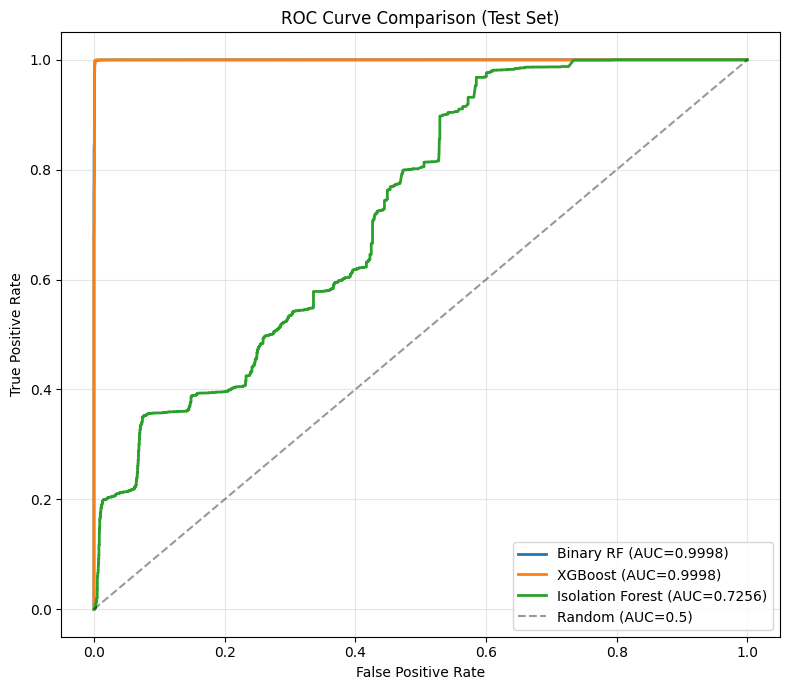

In [5]:
plot_roc_comparison(
    y_test_binary,
    scores,
    title="ROC Curve Comparison (Test Set)",
    save_path=Path(r"C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\docs\figures") / "ml_roc_comparison.png"
)

21:26:56 | Saved PR plot: C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\docs\figures\ml_pr_comparison.png


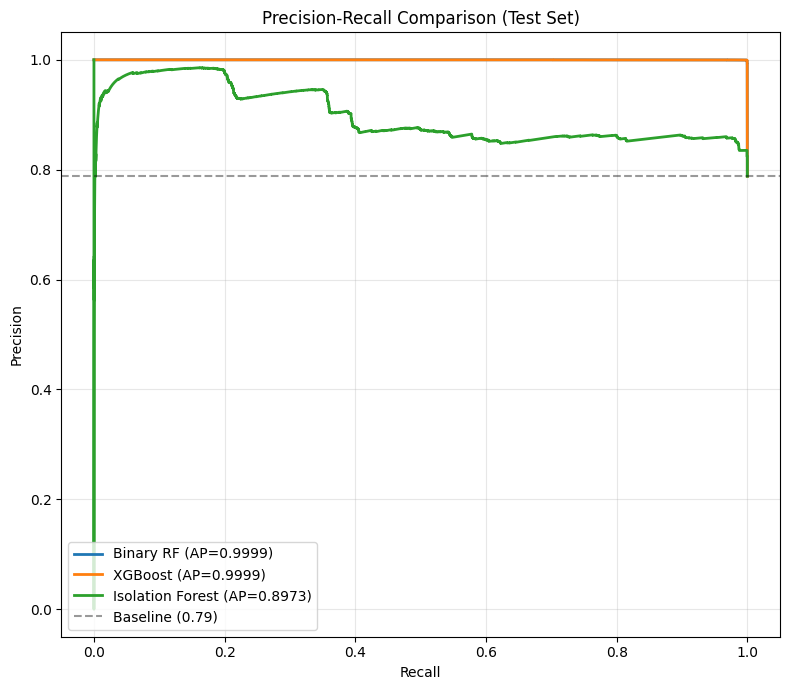

In [6]:
plot_pr_comparison(
    y_test_binary,
    scores,
    title="Precision-Recall Comparison (Test Set)",
    save_path=Path(r"C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\docs\figures") / "ml_pr_comparison.png"
)

In [7]:
print("=" * 70)
print("WHERE EACH MODEL WINS — for Day 6 priority fusion design")
print("=" * 70)

print("\n--- Binary RF (best supervised) ---")
rf_winners = per_class.assign(rf_strength=per_class['Binary RF_pct']).nlargest(5, 'rf_strength')[['class', 'Binary RF_pct']]
print(rf_winners.to_string(index=False))

print("\n--- Isolation Forest (best for rare/novel) ---")
if_winners = per_class.assign(if_strength=per_class['Isolation Forest_pct']).nlargest(5, 'if_strength')[['class', 'Isolation Forest_pct']]
print(if_winners.to_string(index=False))

print("\n--- Where Isolation Forest catches what supervised misses ---")
gap = per_class.copy()
gap['iforest_advantage'] = gap['Isolation Forest_pct'] - gap['Binary RF_pct']
gap_winners = gap[gap['iforest_advantage'] > 0].sort_values('iforest_advantage', ascending=False)[['class', 'n_total', 'Binary RF_pct', 'Isolation Forest_pct', 'iforest_advantage']]
print(gap_winners.to_string(index=False))

WHERE EACH MODEL WINS — for Day 6 priority fusion design

--- Binary RF (best supervised) ---
         class  Binary RF_pct
          DDoS          100.0
Reconnaissance          100.0
  Infiltration          100.0
       Exploit          100.0
           DoS           99.9

--- Isolation Forest (best for rare/novel) ---
       class  Isolation Forest_pct
     Exploit                 100.0
Infiltration                  85.7
         DoS                  63.4
        DDoS                  22.8
      Benign                   6.5

--- Where Isolation Forest catches what supervised misses ---
 class  n_total  Binary RF_pct  Isolation Forest_pct  iforest_advantage
Benign     5000            0.5                   6.5                6.0


In [8]:
print("=" * 70)
print("MODEL SELECTION FOR PRODUCTION")
print("=" * 70)

print("""
Recommendation for Phase 1 production deployment:

  Primary classifier:    XGBoost Multi-Class (xgb_multiclass_v1)
    - Highest specificity for attack family identification
    - Test accuracy: 99.84%, Macro F1: 0.9608
    - Output: priority_label = attack_family
    - Confidence: max(predict_proba) — feed to priority score

  Secondary classifier:  Random Forest Binary (rf_binary_v1)
    - Fast first-pass filter (line-rate filtering)
    - Test AUC: 0.9996
    - Output: P(attack) — feeds to priority score

  Safety net:            Isolation Forest (iforest_v1)
    - Catches novel/rare attacks supervised models miss
    - Critical for Infiltration (57% detection) and Exploit (100% detection)
    - Output: anomaly_score in [0, 1]

The Day 6 priority fusion will combine these into a single priority_score
written back to fact_security_event.
""")

MODEL SELECTION FOR PRODUCTION

Recommendation for Phase 1 production deployment:

  Primary classifier:    XGBoost Multi-Class (xgb_multiclass_v1)
    - Highest specificity for attack family identification
    - Test accuracy: 99.84%, Macro F1: 0.9608
    - Output: priority_label = attack_family
    - Confidence: max(predict_proba) — feed to priority score

  Secondary classifier:  Random Forest Binary (rf_binary_v1)
    - Fast first-pass filter (line-rate filtering)
    - Test AUC: 0.9996
    - Output: P(attack) — feeds to priority score

  Safety net:            Isolation Forest (iforest_v1)
    - Catches novel/rare attacks supervised models miss
    - Critical for Infiltration (57% detection) and Exploit (100% detection)
    - Output: anomaly_score in [0, 1]

The Day 6 priority fusion will combine these into a single priority_score
written back to fact_security_event.

